# Reproduce-then-Extend — Building Energy Efficiency (Engineering)  ·  **Day 1 tutorial**

> **Published study.** Tsanas, A. & Xifara, A. (2012). "Accurate quantitative estimation of energy performance
> of residential buildings using statistical machine learning tools." *Energy and Buildings* 49:560–567. The
> paper's baseline is a **linear regression** predicting a building's heating load from 8 geometry inputs
> (n = 768; UCI id 242). This example illustrates the first regression extension: **polynomial terms**.

## Background

Tsanas and Xifara study how a building's **energy performance** depends on its **design geometry**, to help architects design more efficient buildings. Using 768 simulated building shapes, they estimate the **heating (and cooling) load** from eight geometry inputs, using a **linear regression** as the interpretable baseline alongside nonlinear machine-learning tools. The **primary conclusion** is that energy load is accurately predictable from geometry -- overall height, relative compactness, and glazing are the strongest drivers -- and that flexible learners (random forests) substantially outperform the linear model, motivating their use for this strongly nonlinear relationship.

## Data and codebook

**Unit of analysis:** a simulated residential **building design** (12 shapes and variants, via Ecotect); n = 768.

| Variable | Definition |
|---|---|
| `Y1` | heating load (kWh per m^2 of floor area) **(outcome)** |
| `X1` | relative compactness (volume-to-surface ratio, normalized) |
| `X2` | surface area (m^2) |
| `X3` | wall area (m^2) |
| `X4` | roof area (m^2) |
| `X5` | overall height (m) |
| `X6` | orientation (2/3/4/5 = N/E/S/W) |
| `X7` | glazing area (fraction of floor area) |
| `X8` | glazing-area distribution (0-5 scheme) |

## Descriptive results

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import KFold

In [2]:
url = 'https://raw.githubusercontent.com/desmarais-lab/desmarais-lab.github.io/master/istanbul_bilgi_ml_files/data/ENB2012_data.xlsx'
d = pd.read_excel(url).dropna(axis=1, how='all').dropna()
d = d.rename(columns={c: c for c in d.columns})[['Y1'] + [f'X{i}' for i in range(1, 9)]]
preds = [c for c in d.columns if c != 'Y1']
d.describe().T[['mean','std','min','max']].round(3)

,mean,std,min,max
Y1,22.307,10.090,6.01,43.10
X1,0.764,0.106,0.62,0.98
X2,671.708,88.086,514.50,808.50
X3,318.500,43.626,245.00,416.50
X4,176.604,45.166,110.25,220.50
X5,5.250,1.751,3.50,7.00
X6,3.500,1.119,2.00,5.00
X7,0.234,0.133,0.00,0.40
X8,2.812,1.551,0.00,5.00


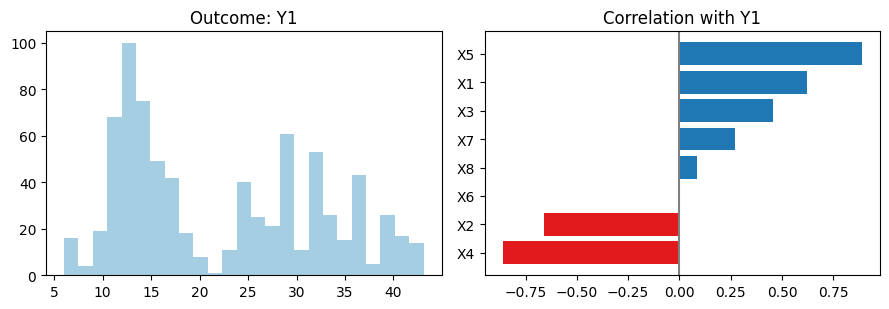

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].hist(d['Y1'], bins=25, color='#a6cee3'); ax[0].set_title('Outcome: Y1')
cors = d[preds].corrwith(d['Y1']).sort_values()
ax[1].barh(cors.index, cors.values, color=['#e31a1c' if v<0 else '#1f78b4' for v in cors])
ax[1].set_title('Correlation with Y1'); ax[1].axvline(0, color='0.5')
plt.tight_layout(); plt.show()

## Reproduce the published regression

In [4]:
lin = sm.OLS(d['Y1'], sm.add_constant(d[preds])).fit()
print(lin.summary())

                            OLS Regression Results                            
Dep. Variable:                     Y1   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     1187.
Date:                Thu, 02 Jul 2026   Prob (F-statistic):               0.00
Time:                        12:57:48   Log-Likelihood:                -1912.5
No. Observations:                 768   AIC:                             3841.
Df Residuals:                     760   BIC:                             3878.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         84.0134     19.034      4.414      0.0

**Confirmation against the published study.** The linear model attains in-sample $R^2$ =
0.916, matching the ~0.92 reported by Tsanas & Xifara for their linear baseline.
Overall height (`X5`) and relative compactness (`X1`) dominate — but the fit leaves clear structure, which is
the motivation for going beyond a straight line.

## Polynomial regression extension

Heating load responds **nonlinearly** to geometry. The classic regression remedy is to add **polynomial
terms**. We compare the linear model to polynomials of increasing degree in relative compactness (`X1`),
keeping the other inputs linear, by choosing the degree with cross-validation on a training set and scoring on a held-out test set.

In [5]:
from sklearn.model_selection import train_test_split, KFold
others = [c for c in preds if c != 'X1']
Dtr_all, Dte = train_test_split(d, test_size=0.30, random_state=2026)   # hold out a 30% test set up front

def design(D, deg):
    return np.column_stack([np.vander(D['X1'], deg + 1, increasing=True)[:, 1:], D[others].values])

# choose the polynomial degree by 5-fold CV on the TRAINING set only
kf = KFold(5, shuffle=True, random_state=2026)
def cv_rmse(deg):
    r = []
    for tr, te in kf.split(Dtr_all):
        A, B = Dtr_all.iloc[tr], Dtr_all.iloc[te]
        m = sm.OLS(A['Y1'], sm.add_constant(design(A, deg))).fit()
        pred = m.predict(sm.add_constant(design(B, deg), has_constant='add'))
        r.append(((B['Y1'] - pred) ** 2).mean() ** 0.5)
    return np.mean(r)
cv = {deg: cv_rmse(deg) for deg in [1, 2, 3, 4]}
best_deg = min(cv, key=cv.get)
print({f'degree {k}': round(v, 4) for k, v in cv.items()})

# refit at the CV-chosen degree on the full training set; score ONCE on the untouched test set
def fit_eval(deg):
    m = sm.OLS(Dtr_all['Y1'], sm.add_constant(design(Dtr_all, deg))).fit()
    pred = m.predict(sm.add_constant(design(Dte, deg), has_constant='add'))
    return ((Dte['Y1'] - pred) ** 2).mean() ** 0.5
test_poly, test_lin = fit_eval(best_deg), fit_eval(1)
print(f'CV-selected degree: {best_deg}.  Held-out test RMSE: polynomial = {test_poly:.4f} vs linear = {test_lin:.4f}')


{'degree 1': np.float64(2.9949), 'degree 2': np.float64(2.9511), 'degree 3': np.float64(2.8663), 'degree 4': np.float64(2.8679)}
CV-selected degree: 3.  Held-out test RMSE: polynomial = 2.7155 vs linear = 2.8902


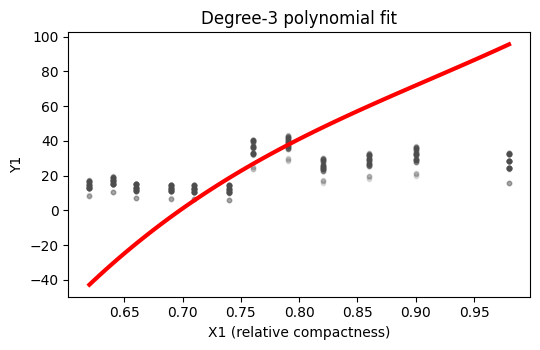

In [6]:
# fitted polynomial curve, holding the other predictors at their means
grid = np.linspace(np.quantile(d['X1'], .02), np.quantile(d['X1'], .98), 100)
Xg = np.column_stack([np.vander(grid, 4, increasing=True)[:,1:],
                      np.tile(d[others].mean().values, (100, 1))])
Xfit = np.column_stack([np.vander(d['X1'], 4, increasing=True)[:,1:], d[others].values])
m = sm.OLS(d['Y1'], sm.add_constant(Xfit)).fit()
yhat = m.predict(sm.add_constant(Xg, has_constant='add'))
plt.figure(figsize=(5.5, 3.6)); plt.scatter(d['X1'], d['Y1'], s=10, alpha=.15, color='0.3')
plt.plot(grid, yhat, 'r-', lw=3); plt.xlabel('X1 (relative compactness)'); plt.ylabel('Y1')
plt.title('Degree-3 polynomial fit'); plt.tight_layout(); plt.show()

The fitted polynomial **curves** with compactness rather than running straight, capturing nonlinearity the
linear model misses while remaining a fully interpretable regression.

## Takeaway

This example illustrates **polynomial regression** as the first, most interpretable extension of a linear
model: adding low-order polynomial terms lowers cross-validated error by bending the fit to the data's
curvature. (Tree-based learners push this further at the cost of a closed-form equation; Tsanas & Xifara
report ML reaching ~0.999 $R^2$ on these data.)

## Recommended exercises

1. Try polynomial degrees 1-5 for the strongest predictor and use cross-validation to choose the degree.
2. Predict the second response (cooling load) and compare which predictors matter most.
3. Add an interaction between two predictors and test whether cross-validated error improves.